In [1]:
from src import *

In [2]:
width = 8.5 / 2.54 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics}'

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

In [3]:
spade_mean = {3: [], 5: []}
spade_var = {3: [], 5: []}
spade_f = {3: [], 5: []}


di_mean = {3: [], 5: []}
di_var = {3: [], 5: []}
di_f = {3: [], 5: []}


for a in (3, 5):
    for f_ in np.linspace(0.1, 0.4, 61):
        f = np.round(f_, 5)
        spade_c = LoadEstimates(f'data/ideal/spade_{a}px_f{f}_d0.npz')
        di_c = LoadEstimates(f'data/ideal/di_{a}px_f{f}_d0.npz')

        spade_f[a].append(spade_c.metadata.ground_truth)
        spade_mean[a].append(spade_c.estimates.mean())
        spade_var[a].append(spade_c.estimates.var(ddof=1) * spade_c.photons)

        di_f[a].append(di_c.metadata.ground_truth)
        di_mean[a].append(di_c.estimates.mean())
        di_var[a].append(di_c.estimates.var(ddof=1) * di_c.photons)

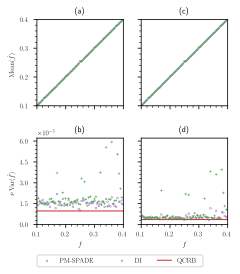

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(width, width*1.1), sharex=True, sharey='row')

axs = {
    3: (ax[0, 0], ax[1, 0]),
    5: (ax[0, 1], ax[1, 1])
}


spade_params = {
    'marker': 'o',
    'edgecolors': '#9467bd',
    'facecolors': 'none',
    's': 3,
    'linewidths': 0.5
}


di_params = {
    'marker': '+',
    'facecolor': '#2ca02c',

    's': 6,
    'linewidths': 0.5
}


for a in (3, 5):
    line1 = axs[a][0].scatter(spade_f[a], spade_mean[a], **spade_params)
    line2 = axs[a][0].scatter(di_f[a], di_mean[a], **di_params)
    # axs[a][0].plot(spade_f[a], spade_mean[a], linewidth=1, linestyle='--')
    # axs[a][0].plot(di_f[a], di_mean[a], linewidth=1, linestyle='-.')

    x_axis = np.linspace(0.1, 0.4, 61)
    fi = DI.ApproxCFI(DMD.A((4/np.pi)*a))
    crb = np.ones(61) / fi
    line3, = axs[a][1].plot(x_axis, crb, '#d62728', linewidth=1, zorder=1)

    axs[a][1].scatter(spade_f[a], spade_var[a], **spade_params)
    axs[a][1].scatter(di_f[a], di_var[a], **di_params)

    # axs[a][0].set_title(rf'${np.round(DMD.A(a)/103, 2)}\sigma$')
    # axs[a][1].set_title(rf'${np.round(DMD.A(a)/103, 2)}\sigma$')


for i, ax_ in enumerate(np.ravel(ax)):
    ax_.set_box_aspect(1)
    ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax_.yaxis.set_minor_locator(AutoMinorLocator(5))
    # ax_.text(-0.15, 1.2, 
    #          [r'$\mathbf{\textsf{(' + _ + r')}}$' for _ in ('a', 'b', 'c', 'd')][i], 
    #          fontsize=9, transform=ax_.transAxes, va='top', ha='left')

ax[0, 0].set_title(r'$\mathbf{\textsf{(a)}}$')
ax[1, 0].set_title(r'$\mathbf{\textsf{(b)}}$')
ax[0, 1].set_title(r'$\mathbf{\textsf{(c)}}$')
ax[1, 1].set_title(r'$\mathbf{\textsf{(d)}}$')


ax[0, 0].set_xlim(0.1, 0.4)
ax[0, 0].set_ylim(0.1, 0.4)
ax[0, 0].set_xticks(np.linspace(0.1, 0.4, 4))
ax[0, 0].set_yticks(np.linspace(0.1, 0.4, 4))

ax[0, 0].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
ax[1, 0].set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')

ax[1, 0].set_xlabel(r'$f$')
ax[1, 1].set_xlabel(r'$f$')
ax[1, 0].set_yticks(np.linspace(0, 6, 5) * 1e-5)
ax[1, 0].yaxis.set_major_formatter(formatter)


fig.legend([line1, line2, line3], ['PM-SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('ideal.pdf')
plt.show()